In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import json
import os
from dotenv import load_dotenv
from openai import OpenAI
from collections import Counter

load_dotenv('')

print("Has OPENAI_API_KEY:", "OPENAI_API_KEY" in os.environ)

DATA_PATH = 'mturk_train_valid.csv'
df = pd.read_csv(DATA_PATH)

# Drop index-like column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df.head()


Has OPENAI_API_KEY: True


,thought,question,label
0,I’m a vegetarian and would hate to eat either....,"So, I assume then you also think that eating h...",assumptions
1,"By our current standards, a child is just as l...",How is that different from a real sword in any...,clarity
2,"Christianity, as I understand it, teaches that...",Why are you yelling?,others
3,There are people in this country who work way ...,What exactly are these barriers preventing peo...,clarity
4,I have. I was paid minimum wage at a job. The ...,What if your job creates only 10 dollars an hour?,implication_consequences


## Data Cleaning

In [2]:
# Clean: inspect then remove duplicates and subreddit-specific terms
df_clean = df.copy()

# Normalize for duplicate detection (case-insensitive, collapse whitespace)
def _norm_text(s):
    return ' '.join(str(s).lower().split())

for col in ['thought', 'question', 'label']:
    df_clean[col + '_norm'] = df_clean[col].apply(_norm_text)

# Pre-drop counts
dup_count = df_clean.duplicated(subset=['thought_norm', 'question_norm', 'label_norm']).sum()
subreddit_pattern = r'(?i)(?:^|\s)(?:r/|/r/|u/|/u/|subreddit|reddit)(?:\s|$)'
subreddit_count = df_clean['question'].str.contains(subreddit_pattern, regex=True).sum()

print(f'Total duplicates (by thought/question/label): {dup_count}')
print(f'Total subreddit/user refs in question: {subreddit_count}')

# Drop duplicates across thought/question/label
df_clean = df_clean.drop_duplicates(subset=['thought_norm', 'question_norm', 'label_norm'])

# Filter subreddit/user references
df_clean = df_clean[~df_clean['question'].str.contains(subreddit_pattern, regex=True)].copy()

# Drop helper columns
df_clean = df_clean.drop(columns=[c for c in df_clean.columns if c.endswith('_norm')])

df_clean.head()

Total duplicates (by thought/question/label): 0
Total subreddit/user refs in question: 9


,thought,question,label
0,I’m a vegetarian and would hate to eat either....,"So, I assume then you also think that eating h...",assumptions
1,"By our current standards, a child is just as l...",How is that different from a real sword in any...,clarity
2,"Christianity, as I understand it, teaches that...",Why are you yelling?,others
3,There are people in this country who work way ...,What exactly are these barriers preventing peo...,clarity
4,I have. I was paid minimum wage at a job. The ...,What if your job creates only 10 dollars an hour?,implication_consequences


In [56]:
df_clean.to_csv('mturk_train_valid_clean.csv', index=False)

## Exploratory Data Analysis

In [3]:
df_clean.shape

(2526, 3)

In [4]:
df_clean.info()


<class 'pandas.DataFrame'>
Index: 2526 entries, 0 to 2534
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   thought   2526 non-null   str  
 1   question  2526 non-null   str  
 2   label     2526 non-null   str  
dtypes: str(3)
memory usage: 78.9 KB


In [5]:
df_clean.isna().sum()

thought     0
question    0
label       0
dtype: int64

In [6]:
df_clean.duplicated().sum()

np.int64(0)

In [7]:
label_counts = df_clean['label'].value_counts()
label_props = df_clean['label'].value_counts(normalize=True).mul(100).round(2)
pd.DataFrame({'count': label_counts, 'percent': label_props})


,count,percent
label,,
implication_consequences,689,27.28
reasons_evidence,663,26.25
clarity,482,19.08
assumptions,415,16.43
alternate_viewpoints_perspectives,242,9.58
others,35,1.39


In [8]:
df_clean

,thought,question,label
0,I’m a vegetarian and would hate to eat either....,"So, I assume then you also think that eating h...",assumptions
1,"By our current standards, a child is just as l...",How is that different from a real sword in any...,clarity
2,"Christianity, as I understand it, teaches that...",Why are you yelling?,others
3,There are people in this country who work way ...,What exactly are these barriers preventing peo...,clarity
4,I have. I was paid minimum wage at a job. The ...,What if your job creates only 10 dollars an hour?,implication_consequences
...,...,...,...
2530,I think the standard of tipping is crazy and g...,Are you arguing against capitalism?,implication_consequences
2531,"I know this is a big yikes to post in 2020, bu...",Why do you care though?,reasons_evidence
2532,But they skirt around paying so often. They're...,And what if someone gets into an accident the ...,implication_consequences
2533,It is important to note that I'm not denying v...,What happened to dinosaurs?,implication_consequences


In [9]:
# Sample questions per label for qualitative review
sample_n = 5  # Number of samples per label

pd.set_option('display.max_colwidth', None)  # No truncation for column width
pd.set_option('display.max_rows', None)     # Show all rows

# Group by label and sample
examples = (
    df_clean[['label', 'thought', 'question']]
    .groupby('label')
    .apply(lambda x: x.sample(min(len(x), sample_n), random_state=42))
)

# Display the sampled examples
examples

thought  \
label                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
alternate_viewpoints_perspectives 234                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            I guess we'll see, but this seems to be a largely reactionary take that doesn't consider the context at all. The US has evacuated over 40,000 people with very little loss of life. We'll never know how avoidable the initial chaos was, but it feels disingenuous to suggest that Trump, who needed securi

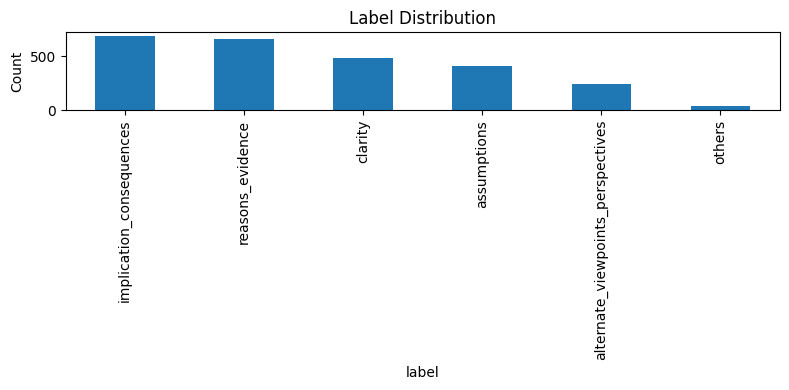

In [55]:
plt.figure(figsize=(8, 4))
label_counts.sort_values(ascending=False).plot(kind='bar')
plt.title('Label Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [11]:
# Text length features
for col in ['thought', 'question']:
    df_clean[f'{col}_char_len'] = df_clean[col].astype(str).str.len()
    df_clean[f'{col}_word_len'] = df_clean[col].astype(str).str.split().apply(len)

df_clean[['thought_char_len', 'thought_word_len', 'question_char_len', 'question_word_len']].describe().T

,count,mean,std,min,25%,50%,75%,max
thought_char_len,2526.0,597.236738,458.911861,50.0,254.0,448.5,799.5,2287.0
thought_word_len,2526.0,105.025337,80.234726,10.0,45.0,79.0,141.0,395.0
question_char_len,2526.0,70.108472,34.631299,10.0,45.0,64.0,88.0,277.0
question_word_len,2526.0,12.792162,6.141496,2.0,8.0,12.0,16.0,46.0


In [13]:
# Lengths by label
df_clean.groupby('label')[['thought_word_len','question_word_len']].mean().round(2).sort_values('thought_word_len', ascending=False)

,thought_word_len,question_word_len
label,,
others,121.49,12.11
implication_consequences,109.60,13.64
alternate_viewpoints_perspectives,108.29,10.85
clarity,102.93,11.23
assumptions,102.40,14.80
reasons_evidence,101.38,12.53


In [15]:
# Examples: shortest/longest by thought length
df_clean.sort_values('thought_word_len').head(5)[['thought','question','label']]

,thought,question,label
591,There is no spectrum though. That's the mental illness talking.,Could you clarify why a person not having a strong feeling that they would be a different person if they were a different sex suggests they have a mental illness?,reasons_evidence
1389,It isn't. Math does not depend on the physical world.,What definition of science are you using?,clarity
2405,You can eat 1000 cakes. You can't live 1000 lives.,And what if you could live another life after this?,implication_consequences
2419,"No, I didn't. I explained my subjective view (""for me"").",Why does your personal view matter?,reasons_evidence
1296,"Sure, I agree. I have nothing against killing animals/plants for food.",Why kill each other and just hinder our own development when we can kill something else?,reasons_evidence


In [16]:
# Longest words in thoughts
df_clean.sort_values('thought_word_len', ascending=False).head(5)[['thought','question','label']]

,thought,question,label
1331,"The baby is a seperate human body, and whether its a living human body is the important distinction when it comes down to the morality of terminating its life. Not in and of itself. A human is technically a human from the moment of conception. I don't care about a human collection of cells at that stage any more than I do a baboon's, or for that matter the bacteria which grow on us. If that fetus is a seperate living human then a womans right to do what she wants with her body doesnt override that lifes right to not be killed. I'm saying it necessarily warrants removal. The mother has a right to complete choice in terms of what she wants in and of her body. We dont solve our problems outside the womb by terminating lives. when one impedes on our bodily autonomy and we both wish to and have the capacity to remove them we do so in the least restrictive manner that does not further impede on our bodily autonomy or capacity to maintain it. Is this a reason for a different style of removal? Maybe, but because I can't see a procedure which doesn't necessarily do impede on her autonomy further and in a significant way, I'm inclined to support allowing the mother to choose the method of removal which works for her and which a physician is inclined to support. Why solve problems inside the womb by terminating a life? Because the person on which the fetus/baby is dependent on chooses to. The ultimate moral question is if that fetus is a seperate human life, and if human life has any value worth protecting. Not typically. For many people the line is whether it is meaningfully a person. This includes attributes such as rationality, feeling etc. Even by committing suicide and terminating yourself you can be criminally charged. No, at least here you can't. Physician assisted suicide is an entirely different conversation when it comes to the medical termination of life, as that patient is deciding their own fate, not the fate of the body they carry. Of course it is, I was just countering the assertion that bodily autonomy is not considered a heavily valued right in this society to the point where it means that terminating a life is not in all cases a criminal offense.",Is terminating lives other than your own illegal wherever you live?,implication_consequences
2268,"I was in a similar boat and ended up becoming Catholic (after marrying a Catholic). One thing that surprised me was how little I knew about the most popular Christian church before I started researching it closely. Here are my responses to your issues. Granted I can't speak for the church, but this is how I see things: Creationism and certain views that contradict plausible science that has been proven again and again. The Catholic church has no problem with the theory of evolution or any of the other commonly accepted scientific theories as far as I'm aware. We do not hold to any strict creationist view of the world, so there is no problem here at all. The fact that there is such a harsh distinction between the two possible afterlives: endless punishment or endless paradise, and the fact that someone evil like Ted Bundy, ""confessed"" and apologized for his sins before execution, would be sent to Heaven and a virtuous, amazing human being like Bill Gates would be sent to Hell because he is an atheist. I'm not an expert on this, but I believe the Catholic church does not actually believe in a strict heaven vs. hell. There is at least heaven, purgatory, the resurrection, and hell. Personally, I do not think most people who are non-Christian or unbaptized when they die go to hell, but I'm not sure what the official church statement on that is. Anti-gay, anti-contraception and other repressive movements in the name of religion. This is a bit of an issue admittedly in the church. However, in our defense I would say that the Catholic church permits more disagreement within it than most churches. Officially the church is against contraception, for example,

Reframe evaluation of Relevance + Coherenece as Groundeness since both of these metrics relies on the use of previous conversation turns and survey objectives.

In [17]:
LLM_AS_A_JUDGE_PROMPT = """
You are an evaluation assistant.

Inputs:
1. Thought: {{thought}}
2. Candidate follow-up question: {{question}}

Task:
Evaluate the follow-up question using the four dimensions defined below.
Each dimension must be scored on a continuous scale from 0.0 to 1.0 (inclusive).

Evaluation dimensions:

Groundedness (GRD):
How directly and logically does the follow-up question arise from the given thought?
- 1.0 = clearly grounded and naturally motivated by the thought
- 0.0 = unrelated or weakly connected

Informativeness (INFO):
How much new, useful information is the question likely to elicit beyond what is already
implied by the thought?
- 1.0 = likely to elicit rich, specific information
- 0.0 = trivial or redundant

Truthfulness (TRUTH):
Does this question ask about a valid kind of attribute or relation for the given entity, 
rather than presupposing something impossible or nonsensical?
- 1.0 = presuppositions are clearly valid
- 0.0 = presuppositions are clearly invalid or nonsensical

Clarity (CLA):
How clear, grammatical, and unambiguous is the question?
- 1.0 = clear and natural
- 0.0 = unclear or ambiguous

Output requirements:
- Return ONLY valid JSON.
- Do NOT include markdown or extra text.
- Each explanation must be a single concise sentence (≤20 words).
- Scores must be numeric floats between 0.0 and 1.0.

Output format:
{
  "groundedness": {"score": <float>, "explanation": "<short sentence>"},
  "informativeness": {"score": <float>, "explanation": "<short sentence>"},
  "truthfulness": {"score": <float>, "explanation": "<short sentence>"},
  "clarity": {"score": <float>, "explanation": "<short sentence>"}
}
"""


In [18]:
client = OpenAI()

In [21]:
def format_judge_prompt(thought: str, question: str) -> str:
    return LLM_AS_A_JUDGE_PROMPT.replace("{{thought}}", thought).replace("{{question}}", question)

def evaluate_pair(thought: str, question: str) -> dict:
    prompt = format_judge_prompt(thought, question)

    resp = client.responses.create(
        model="gpt-4.1-nano",   # or another model you prefer
        input=prompt,
        max_output_tokens=300,
        temperature=0
    )

    text = resp.output[0].content[0].text
    return json.loads(text)

In [24]:
# Test for 1 Row
row = df_clean.iloc[2]
print(row)
scores = evaluate_pair(row["thought"], row["question"])
scores

thought              Christianity, as I understand it, teaches that we all deserve hell. God is perfect and holy and all people have sinned against him and rejected him. Because of this sin, all people have separated themselves from God, by doing their will instead of his. Jesus died to take the punishment for these sins and reconcile us to God. No one deserves this gift, and it is by God's grace that anyone is saved. Therefore, it's not unjust for anyone to go to hell, it is what we all deserve. This presupposes a very Western, modern understanding of justice and the individual. Not everyone would disregard our collective guilt. While we all are predisposed to sin, indeed some Christians would say every single thing we do is tainted by sin, we also have free will. Even if you disregarded 99% of our sin, every single person has used their free will to intentionally break God's laws. I'd also add that apart from God there can be no objective morality, other than what is right in our own

{'groundedness': {'score': 0.8,
  'explanation': 'The question relates to the tone of the thought, which is about emotional expression.'},
 'informativeness': {'score': 0.2,
  'explanation': "It does not elicit new or detailed information about the thought's content."},
 'truthfulness': {'score': 1.0,
  'explanation': 'The question presumes that yelling is a recognizable and valid behavior.'},
 'clarity': {'score': 1.0,
  'explanation': 'The question is clear, direct, and grammatically correct.'}}

In [27]:
# Test for another Row
row = df_clean.iloc[4]
print(row)
scores = evaluate_pair(row["thought"], row["question"])
scores

thought              I have. I was paid minimum wage at a job. The company knew it would not gain anything by raising the wages, so it didn't. That's evil. No one should be making $8/hr
question                                                                                                                                What if your job creates only 10 dollars an hour?
label                                                                                                                                                            implication_consequences
thought_char_len                                                                                                                                                                      164
thought_word_len                                                                                                                                                                       33
question_char_len                                                     

{'groundedness': {'score': 0.8,
  'explanation': 'The question relates to the value created by the job, which connects to the thought.'},
 'informativeness': {'score': 0.7,
  'explanation': 'It prompts consideration of how job value impacts wage fairness.'},
 'truthfulness': {'score': 1.0,
  'explanation': 'The question presumes a plausible scenario about job earnings.'},
 'clarity': {'score': 1.0,
  'explanation': 'The question is clear, grammatically correct, and unambiguous.'}}

## Applying Evaluation across entire dataset

In [26]:
def format_judge_prompt(thought: str, question: str) -> str:
    return LLM_AS_A_JUDGE_PROMPT.replace("{{thought}}", thought).replace("{{question}}", question)

BATCH_INPUT_PATH = "judge_batch_input.jsonl"

with open(BATCH_INPUT_PATH, "w", encoding="utf-8") as f:
    for idx, row in df_clean.iterrows():
        # Format Prompt
        prompt = format_judge_prompt(row["thought"], row["question"])

        # Prepare json line
        req = {
            "custom_id": f"row-{idx}",
            "method": "POST",
            "url": "/v1/responses",
            "body": {
                "model": "gpt-4.1-nano",
                "input": prompt,
                "max_output_tokens": 300,
                "temperature": 0
            }
        }
        f.write(json.dumps(req, ensure_ascii=False) + "\n")

In [28]:
import requests

load_dotenv()
api_key = os.environ["OPENAI_API_KEY"]

# 1) Upload the JSONL file
with open("judge_batch_input.jsonl", "rb") as f:
    upload_resp = requests.post(
        "https://api.openai.com/v1/files",
        headers={"Authorization": f"Bearer {api_key}"},
        files={"file": ("judge_batch_input.jsonl", f, "application/jsonl")},
        data={"purpose": "batch"}
    )
upload_resp.raise_for_status()
file_id = upload_resp.json()["id"]
print("Uploaded file id:", file_id)

# 2) Create the batch job
batch_resp = requests.post(
    "https://api.openai.com/v1/batches",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    },
    json={
        "input_file_id": file_id,
        "endpoint": "/v1/responses",
        "completion_window": "24h"
    }
)
batch_resp.raise_for_status()
batch = batch_resp.json()
batch_id = batch["id"]
batch_id

Uploaded file id: file-7C3HniAtKAqWjKkMDJoV6h


'batch_69816021f5148190b1f09990863b531b'

In [40]:
# Query batch progress
client = OpenAI()
batch = client.batches.retrieve(batch_id)
print(batch)
print(batch.status)
print(batch.output_file_id)

output_file_id = batch.output_file_id

Batch(id='batch_69816021f5148190b1f09990863b531b', completion_window='24h', created_at=1770086433, endpoint='/v1/responses', input_file_id='file-7C3HniAtKAqWjKkMDJoV6h', object='batch', status='completed', cancelled_at=None, cancelling_at=None, completed_at=1770086883, error_file_id=None, errors=None, expired_at=None, expires_at=1770172833, failed_at=None, finalizing_at=1770086732, in_progress_at=1770086496, metadata=None, model='gpt-4.1-nano-2025-04-14', output_file_id='file-XniKdSUbmjcwrDjtMNPBY7', request_counts=BatchRequestCounts(completed=2526, failed=0, total=2526), usage=BatchUsage(input_tokens=1364551, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=343385, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=1707936))
completed
file-XniKdSUbmjcwrDjtMNPBY7


In [43]:
# Get batch results
file_response = client.files.content(output_file_id)

# Save raw text to a JSONL file
OUTPUT_JSONL_PATH = "judge_batch_output.jsonl"
with open(OUTPUT_JSONL_PATH, "w", encoding="utf-8") as f:
    f.write(file_response.text)

print(f"Saved batch output to {OUTPUT_JSONL_PATH}")

Saved batch output to judge_batch_output.jsonl


In [58]:
import json

responses = []
with open("judge_batch_output.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        obj = json.loads(line)
        responses.append(obj["response"]["body"]["output"][0])

In [64]:
rows = []
for i, r in enumerate(responses):
    text = r["content"][0]["text"]
    try:
        scores = json.loads(text)
    except json.JSONDecodeError:
        # skip this bad row
        print(f"Skipping row:{i}")
        continue

    rows.append({
        "row_id": i,
        "groundedness": scores["groundedness"]["score"],
        "informativeness": scores["informativeness"]["score"],
        "truthfulness": scores["truthfulness"]["score"],
        "clarity": scores["clarity"]["score"],
    })

df_scores = pd.DataFrame(rows)
df_scores.head()

Skipping row:1925
Skipping row:2130
Skipping row:2320
Skipping row:2367


,row_id,groundedness,informativeness,truthfulness,clarity
0,0,0.9,0.8,1.0,1.0
1,1,0.9,0.8,1.0,1.0
2,2,0.8,0.2,1.0,1.0
3,3,0.9,0.8,1.0,1.0
4,4,0.8,0.6,1.0,1.0


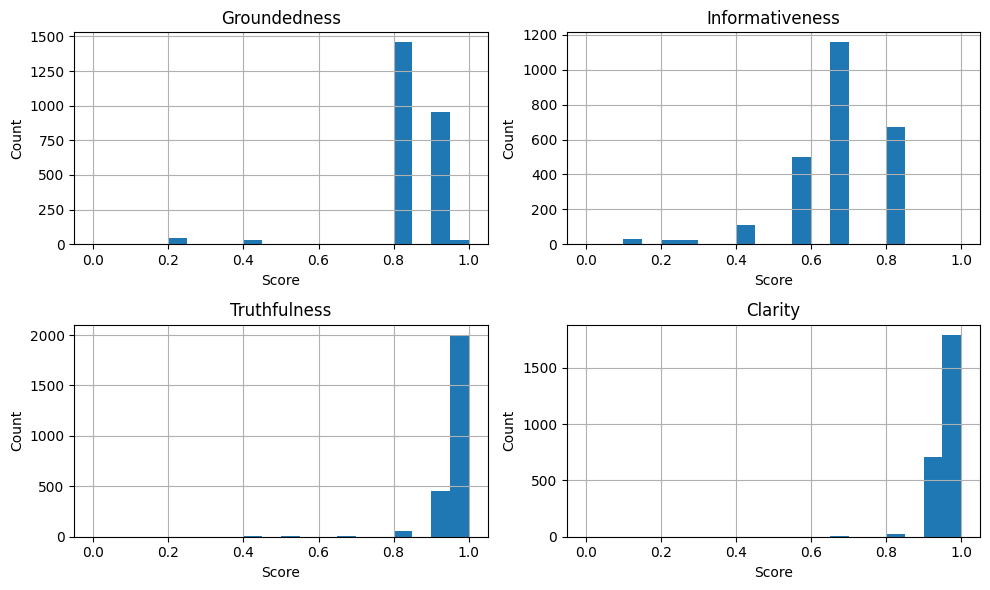

In [65]:
import matplotlib.pyplot as plt

metrics = ["groundedness", "informativeness", "truthfulness", "clarity"]

plt.figure(figsize=(10, 6))
for i, m in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    df_scores[m].hist(bins=20, range=(0, 1))
    plt.title(m.capitalize())
    plt.xlabel("Score")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

Merging evaluated dataset with original columns

In [69]:
df_clean_reset = df_clean.reset_index().rename(columns={"index": "row_id"})

df_merged = df_clean_reset.merge(df_scores, on="row_id", how="inner")

# Keep only thought, question, label and the 4 metrics (plus row_id if you want)
cols = [
    "row_id",
    "thought",
    "question",
    "label",
    "groundedness",
    "informativeness",
    "truthfulness",
    "clarity",
]

df_merged = df_merged[cols]
df_merged.head()

,row_id,thought,question,label,groundedness,informativeness,truthfulness,clarity
0,0,"I’m a vegetarian and would hate to eat either. But I’ve seen several news articles recently about campaigners trying to pressure China and other Asian countries into banning the killing and consumption of dogs. To me, there is no moral difference between the two. I find it paradoxical to be in favour of killing and eating pigs and cows, but not dogs. I’d appreciate a member of the anti-dog-eating community to try and enlighten me.","So, I assume then you also think that eating human is the same then?",assumptions,0.9,0.8,1.0,1.0
1,1,"By our current standards, a child is just as likely to see a Jedi kill a guy with a lightsaber- and anthropomorphic animals without any clothes on. Consider the degrees removed from realism. Breasts, alien or not, is pretty close to real breasts, and they are real if it's live-action. Comparatively, a lightsaber is far less real than a sword, and it's definitely less real than actual exposed onscreen breasts.",How is that different from a real sword in any meaningful way?,clarity,0.9,0.8,1.0,1.0
2,2,"Christianity, as I understand it, teaches that we all deserve hell. God is perfect and holy and all people have sinned against him and rejected him. Because of this sin, all people have separated themselves from God, by doing their will instead of his. Jesus died to take the punishment for these sins and reconcile us to God. No one deserves this gift, and it is by God's grace that anyone is saved. Therefore, it's not unjust for anyone to go to hell, it is what we all deserve. This presupposes a very Western, modern understanding of justice and the individual. Not everyone would disregard our collective guilt. While we all are predisposed to sin, indeed some Christians would say every single thing we do is tainted by sin, we also have free will. Even if you disregarded 99% of our sin, every single person has used their free will to intentionally break God's laws. I'd also add that apart from God there can be no objective morality, other than what is right in our own eyes, which isn't really the same thing. edit: formatting - sorry for the yelling!",Why are you yelling?,others,0.8,0.2,1.0,1.0
3,3,"There are people in this country who work way more than 40 hours a week and still do not make a living wage. Some of us can not simply ""develop skills"" to get a different job. For some of us, there is a systemic, class, or economic institutionalized barrier that prevents change.",What exactly are these barriers preventing people from learning?,clarity,0.9,0.8,1.0,1.0
4,4,"I have. I was paid minimum wage at a job. The company knew it would not gain anything by raising the wages, so it didn't. That's evil. No one should be making $8/hr",What if your job creates only 10 dollars an hour?,implication_consequences,0.8,0.6,1.0,1.0


In [70]:
# Compute average across the 4 metrics
metric_cols = ["groundedness", "informativeness", "truthfulness", "clarity"]
df_merged["avg_score"] = df_merged[metric_cols].mean(axis=1)

# Sort by average score descending
df_merged_sorted = df_merged.sort_values("avg_score", ascending=False)

# Take top 600 rows
top_600 = df_merged_sorted.head(600)

top_600.head()

,row_id,thought,question,label,groundedness,informativeness,truthfulness,clarity,avg_score
2512,2525,"You know that a transman can accept that he has breasts and still being dysphoric about it? I... disagree. If you accept who you are, then there is no ""variance"". I mean do you think therapy could change your sexuality? Make you attracted to men and at the same time take the attraction for women? Or even change what gender you identify as? It not about 'changing' anything, it's about realizing the truth. And that is that you are who you are, and it's fine to be who you are, and that you don't need to change.",What is the truth in your eyes?,clarity,1.0,0.8,1.0,1.0,0.95
1008,1011,"""All lives matter"" came out as a refute to ""Black lives matter"". Prior to Black Lives Matter, there was no mention of All Lives Matter. But I would instead argue that ""All"" in this case is being used as a pejorative against black and brown people. And in that case, it is referring to whites.",Why do you assume its only used pejoratively?,assumptions,1.0,0.8,1.0,1.0,0.95
719,721,"It will still be on the public mind. Opiates are on the public mind right now, and they arent legal",And how many people try opiates?,reasons_evidence,1.0,0.8,1.0,1.0,0.95
2240,2251,"Educating the youth is a matter of utmost importance, Rooh! Rooh! to enable free choice they must be free from gender roles right from a young age. What? How did you decide this? Do you feel like you have the right to force your own view of gender roles or non-roles onto others? Which is what feminists advocate for.",What else is feminism advocating for then?,alternate_viewpoints_perspectives,1.0,0.8,1.0,1.0,0.95
2215,2225,The first two paragraphs are detailing how pedophilia is a developed trait. And we don't tolerate psychopaths that don't kill either.,What makes you think that?,reasons_evidence,1.0,0.8,1.0,1.0,0.95


In [71]:
top_600.to_csv("finetuning600.csv", index=False)

## Pre-Finetuning Evaluation

Testing Ollama's Local Inference

In [73]:
from ollama import chat

response = chat(
    model='gemma3:4b',
    messages=[{'role': 'user', 'content': 'Hello! I want to play a game with you!'}],
)
print(response.message.content)

Great! I love playing games. 😊 

What kind of game are you thinking of? Here are a few ideas to get us started:

* **20 Questions:** You think of something, and I'll try to guess it in 20 questions or less.
* **Trivia:** We can quiz each other on a topic.
* **Storytelling:** We can take turns adding sentences to build a story.
* **Number Guessing:** I pick a number, and you try to guess it.
* **Would You Rather:** We can ask each other silly "Would you rather..." questions.

Or, if you have something else in mind, let me know!  What sounds fun to you?


In [74]:
SYSTEM = """You are a Socratic questioning engine.

Goal: advance the user's thinking by asking ONE precise question.
You must not provide answers, explanations, advice, or moral judgments.

Hard constraints:
- Output exactly 1 line.
- That line must start with: "Question: "
- Ask exactly ONE question (end with a single '?').
- No preamble, no bullet points, no extra text.
- Non-leading: do not imply the “right” answer.
- Make it answerable but non-trivial.
- Avoid jargon unless it appears in the context.
- Target the specified Socratic focus only.
"""

context = "I think finetuning on Reddit will inevitably make my model toxic."
focus = "Probing reasons and evidence"

USER = f"""Context:
{context}

Socratic focus:
{focus}

Write one Socratic question that fits the focus and challenges the user’s thinking.
"""

resp = chat(
    model="gemma3:4b",
    messages=[
        {"role": "system", "content": SYSTEM},
        {"role": "user", "content": USER},
    ],
)

print(resp.message.content)

Question: What specific aspects of Reddit’s content lead you to believe finetuning will inherently result in toxicity?


In [104]:
# 1) Load test set
df_test = pd.read_csv("data/mturk_test.csv").copy()

# 2) Map labels -> Socratic focus (adjust if your test labels differ)
LABEL_TO_FOCUS_MAPPING = {
    "clarity": "Clarification",
    "assumptions": "Probing assumptions",
    "reasons_evidence": "Probing reasons and evidence",
    "implication_consequences": "Probing implications and consequences",
    "alternate_viewpoints_perspectives": "Probing alternative viewpoints and perspectives",
    "others": "Meta/reflection",
}

def map_focus(label: str) -> str:
    return LABEL_TO_FOCUS_MAPPING.get(str(label), "Meta/reflection")

In [105]:
# 3) System prompt (single-line output constraints)
SYSTEM_SOCRATIC = """You are a Socratic questioning engine.

Goal: advance the user's thinking by asking ONE precise question.
You must not provide answers, explanations, advice, or moral judgments.

Hard constraints:
- Output exactly 1 line.
- That line must start with: "Question: "
- Ask exactly ONE question (end with a single '?').
- No preamble, no bullet points, no extra text.
- Non-leading: do not imply the “right” answer.
- Make it answerable but non-trivial.
- Avoid jargon unless it appears in the context.
- Target the specified Socratic focus only.
"""

# 4) One-row generation function
def generate_followup_gemma(thought: str, question: str, focus: str, model: str = "gemma3:4b") -> str:
    user_prompt = f"""Context:
{thought}

Original question:
{question}

Socratic focus:
{focus}

Write one Socratic question that fits the focus and challenges the user’s thinking."""
    resp = chat(
        model=model,
        messages=[
            {"role": "system", "content": SYSTEM_SOCRATIC},
            {"role": "user", "content": user_prompt},
        ],
    )
    return resp.message.content.strip()

# 5) Batch runner (optionally sample, and save outputs)
def run_batch_generation(
    df: pd.DataFrame,
    out_csv_path: str = "test_followups_gemma.csv",
    model: str = "gemma3:4b",
    sample_n: int | None = None,
    random_state: int = 42,
) -> pd.DataFrame:
    work = df.copy()

    # Optional sampling
    if sample_n is not None:
        work = work.sample(n=sample_n, random_state=random_state).copy()

    # Ensure required columns exist
    required = {"thought", "question", "label"}
    missing = required - set(work.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Compute focus per row
    work["focus"] = work["label"].apply(map_focus)

    # Generate followups
    followups = []
    errors = []
    for i, row in work.iterrows():
        try:
            fup = generate_followup_gemma(
                thought=str(row["thought"]),
                question=str(row["question"]),
                focus=str(row["focus"]),
                model=model,
            )
            followups.append(fup)
            errors.append(None)
        except Exception as e:
            followups.append(None)
            errors.append(str(e))
            print(f"[error] row_index={i}: {e}")

    work["model"] = model
    work["generated_followup"] = followups
    work["generation_error"] = errors

    # Save
    work.to_csv(out_csv_path, index=False)
    print(f"Saved {len(work)} rows to {out_csv_path}")
    return work

In [107]:
# 6) Execute on full test set (or set sample_n=120, etc.)
df_test_generated = run_batch_generation(
    df=df_test,
    out_csv_path="data/mturk_test_gemma_followups.csv",
    model="gemma3:4b",
    sample_n=120,  # set to an int to test quickly
)

df_test_generated.head()

Saved 120 rows to data/mturk_test_gemma_followups.csv


,Unnamed: 0,thought,question,label,focus,model,generated_followup,generation_error
396,396,Because the Rangers face a serious deficiency in their ability to perform their duties without women in their group. There are things that women can do in terms of interacting with target regions and communities which male rangers are simply unable to.,Why would these women need to be Rangers in order to interact with the communities on behalf of the Rangers?,reasons_evidence,Probing reasons and evidence,gemma3:4b,Question: What specific limitations regarding community interaction do male Rangers currently possess?,None
248,248,Don't think politically conservative. Think more slow to change and holding onto tradition. How is restricting the hairstyles you can have not egalitarian. Also the military is a expressly hierarchical society. To simplify Ncos are better then Joes. Senior NCOs are better then ncos and joes. Officers are better then senior ncos ncos and Joes. And to break from this hierarchy has financial and physical punishments attached.,Are you suggesting that men and women belong in different places in the hierarchy?,implication_consequences,Probing implications and consequences,gemma3:4b,Question: What assumptions about capability are embedded within this hierarchical structure?,None
215,215,"No, it doesn't. The study only looked at exploited children.",Do you really think it is not important to look at the reality that young girls are being forced into sex work?,others,Meta/reflection,gemma3:4b,Question: What assumptions are you making about the significance of this particular study?,None
353,353,"I can think of absolutely no situations where the death sentence is an ethically valid option. Criminal courts should not serve to provide satisfaction for the victims (this is the realm of civil court), and before assigning a death sentence, certain conditions must first be met: 1. The criminal must be guilty beyond any shred of doubt 2. The criminal must be mentally well (else we instead must provide mental healthcare as they can not be considered responsible for their actions) 3. The criminal must have failed in our efforts to rehabilitate them This presents a sort of catch-22. If the criminal is mentally well, it should be possible to rehabilitate them, as failing to do so would mean their death. If they fail to be rehabilitated, it must mean that they are either mentally unwell or they wish to die. If they wish to die, then that is their own prerogative and they have the natural right to commit suicide. If they do not wish to die, then we must interpret them as being mentally ill and we are therefore obligated to see to helping them. Furthermore, we must question what (if anything) gives the state the right to end their life.",Do you believe the state has a duty to protect its citizens from individuals who use murder as either sport or as a means of conflict resolution?,implication_consequences,Probing implications and consequences,gemma3:4b,"Question: Considering your outlined conditions for capital punishment, what inherent value do you assume a human life possesses?",None
548,548,"I respect this opinion. However, do you not feel that this only applies if the individual in question does not demand support from society if they choose to ruin their health? Also, people are still able to eat unhealthy food in this scenario, they just need to compensate society in line with the true cost of their choice.",Are you assuming there is some sort of universal healthcare program in place in your scenario?,assumptions,Probing assumptions,gemma3:4b,"Question: What factors, beyond individual choice, might determine the “true cost” of unhealthy eating?",None


## Evaluating A: Original Test Set Follow-Up Questions against B: Gemma3:4b's follow-up questions

In [110]:
import json
import re
import os

# Load the file we just generated with Gemma responses
TEST_GEN_PATH = "data/mturk_test_gemma_followups.csv"
df_test_gen = pd.read_csv(TEST_GEN_PATH)

BATCH_TEST_INPUT_PATH = "data/judge_batch_input_test.jsonl"

def clean_generated_question(q):
    if pd.isna(q): return ""
    # Remove leading "Question: " if present, as prompt might have generated it
    return re.sub(r"^Question:\s*", "", str(q), flags=re.IGNORECASE).strip()

with open(BATCH_TEST_INPUT_PATH, "w", encoding="utf-8") as f:
    for idx, row in df_test_gen.iterrows():
        # 1. Evaluate Original Question
        prompt_orig = format_judge_prompt(row["thought"], row["question"])
        req_orig = {
            "custom_id": f"row-{idx}-original",
            "method": "POST",
            "url": "/v1/responses",
            "body": {
                "model": "gpt-4.1-nano", # Using the same model as training data cleaning
                "input": prompt_orig,
                "max_output_tokens": 300,
                "temperature": 0
            }
        }
        f.write(json.dumps(req_orig, ensure_ascii=False) + "\n")
        
        # 2. Evaluate Gemma Question (if exists)
        gemma_q = clean_generated_question(row["generated_followup"])
        if gemma_q:
            prompt_gemma = format_judge_prompt(row["thought"], gemma_q)
            req_gemma = {
                "custom_id": f"row-{idx}-gemma",
                "method": "POST",
                "url": "/v1/responses",
                "body": {
                    "model": "gpt-4.1-nano",
                    "input": prompt_gemma,
                    "max_output_tokens": 300,
                    "temperature": 0
                }
            }
            f.write(json.dumps(req_gemma, ensure_ascii=False) + "\n")

print(f"Prepared batch input for test evaluation: {BATCH_TEST_INPUT_PATH}")

Prepared batch input for test evaluation: data/judge_batch_input_test.jsonl


In [111]:
# Upload and Submit Batch Job for Test Set
import requests

with open(BATCH_TEST_INPUT_PATH, "rb") as f:
    upload_resp = requests.post(
        "https://api.openai.com/v1/files",
        headers={"Authorization": f"Bearer {api_key}"},
        files={"file": (BATCH_TEST_INPUT_PATH, f, "application/jsonl")},
        data={"purpose": "batch"}
    )
upload_resp.raise_for_status()
test_file_id = upload_resp.json()["id"]
print("Uploaded test file id:", test_file_id)

batch_resp = requests.post(
    "https://api.openai.com/v1/batches",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    },
    json={
        "input_file_id": test_file_id,
        "endpoint": "/v1/responses",
        "completion_window": "24h"
    }
)
batch_resp.raise_for_status()
batch_test = batch_resp.json()
batch_test_id = batch_test["id"]
print("Batch ID:", batch_test_id)

Uploaded test file id: file-8MjCjkQzzttLncnbDVShdW
Batch ID: batch_698bdfce3ddc819096b364c952671262
Batch ID: batch_698bdfce3ddc819096b364c952671262


In [115]:
# Check Batch Status
client = OpenAI()
batch_status = client.batches.retrieve(batch_test_id)
print(f"Status: {batch_status.status}")
if batch_status.output_file_id:
    print(f"Output File ID: {batch_status.output_file_id}")

Status: completed
Output File ID: file-JAYMzW9MN4svYStT2zVVMC


In [116]:
# Once completed, retrieve results
OUTPUT_TEST_JSONL = "judge_batch_output_test.jsonl"

if batch_status.status == "completed" and batch_status.output_file_id:
    file_response = client.files.content(batch_status.output_file_id)
    
    with open(OUTPUT_TEST_JSONL, "w", encoding="utf-8") as f:
        f.write(file_response.text)
        
    print(f"Saved results to {OUTPUT_TEST_JSONL}")
else:
    print("Batch not yet completed. Re-run this cell later.")

Saved results to judge_batch_output_test.jsonl


In [117]:
# Process results and merge back
results_map = {}

# Only proceed if we have a result file
if os.path.exists(OUTPUT_TEST_JSONL):
    with open(OUTPUT_TEST_JSONL, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip(): continue
            data = json.loads(line)
            custom_id = data["custom_id"] # format: row-{idx}-{type}
            
            # Extract scores
            response_body = data["response"]["body"]
            if response_body:
                output_text = response_body["output"][0]["content"][0]["text"]
                try:
                    scores = json.loads(output_text)
                    
                    # Parse custom_id
                    parts = custom_id.split("-")
                    # custom_id format can be "row-123-original" or "row-123-gemma"
                    row_idx = int(parts[1])
                    eval_type = parts[2] # "original" or "gemma"
                    
                    if row_idx not in results_map:
                        results_map[row_idx] = {}
                    
                    results_map[row_idx][eval_type] = scores
                except Exception as e:
                    print(f"Error parsing row {custom_id}: {e}")

    # Build comparison DataFrame
    comparison_rows = []
    for idx, row in df_test_gen.iterrows():
        res = results_map.get(idx, {})
        
        row_data = {
            "row_id": idx,
            "label": row["label"],
            "thought": row["thought"],
            "original_question": row["question"],
            "gemma_question": row["generated_followup"]
        }
        
        # Add original scores
        orig_scores = res.get("original", {})
        for k in ["groundedness", "informativeness", "truthfulness", "clarity"]:
            row_data[f"orig_{k}"] = orig_scores.get(k, {}).get("score", None)
            
        # Add gemma scores
        gemma_scores = res.get("gemma", {})
        for k in ["groundedness", "informativeness", "truthfulness", "clarity"]:
            row_data[f"gemma_{k}"] = gemma_scores.get(k, {}).get("score", None)
            
        comparison_rows.append(row_data)

    df_results = pd.DataFrame(comparison_rows)
    print("First 5 result rows:")
    display(df_results.head())
    
    # Simple aggregation comparison
    print("\n--- Original Questions Average Scores ---")
    print(df_results[[c for c in df_results.columns if c.startswith("orig_") and c != "original_question"]].mean())
    
    print("\n--- Gemma Generated Questions Average Scores ---")
    print(df_results[[c for c in df_results.columns if c.startswith("gemma_") and c != "gemma_question"]].mean())
    df_results.to_csv("data/test_set_evaluation_results.csv", index=False)
else:
    print(f"Result file {OUTPUT_TEST_JSONL} not found yet.")

Error parsing row row-111-gemma: Expecting ',' delimiter: line 4 column 73 (char 324)
First 5 result rows:


,row_id,label,thought,original_question,gemma_question,orig_groundedness,orig_informativeness,orig_truthfulness,orig_clarity,gemma_groundedness,gemma_informativeness,gemma_truthfulness,gemma_clarity
0,0,reasons_evidence,Because the Rangers face a serious deficiency in their ability to perform their duties without women in their group. There are things that women can do in terms of interacting with target regions and communities which male rangers are simply unable to.,Why would these women need to be Rangers in order to interact with the communities on behalf of the Rangers?,Question: What specific limitations regarding community interaction do male Rangers currently possess?,0.8,0.7,1.0,1.0,0.9,0.8,1.0,1.0
1,1,implication_consequences,Don't think politically conservative. Think more slow to change and holding onto tradition. How is restricting the hairstyles you can have not egalitarian. Also the military is a expressly hierarchical society. To simplify Ncos are better then Joes. Senior NCOs are better then ncos and joes. Officers are better then senior ncos ncos and Joes. And to break from this hierarchy has financial and physical punishments attached.,Are you suggesting that men and women belong in different places in the hierarchy?,Question: What assumptions about capability are embedded within this hierarchical structure?,0.8,0.6,0.9,0.9,0.9,0.8,1.0,1.0
2,2,others,"No, it doesn't. The study only looked at exploited children.",Do you really think it is not important to look at the reality that young girls are being forced into sex work?,Question: What assumptions are you making about the significance of this particular study?,0.8,0.7,1.0,0.9,0.8,0.7,1.0,1.0
3,3,implication_consequences,"I can think of absolutely no situations where the death sentence is an ethically valid option. Criminal courts should not serve to provide satisfaction for the victims (this is the realm of civil court), and before assigning a death sentence, certain conditions must first be met: 1. The criminal must be guilty beyond any shred of doubt 2. The criminal must be mentally well (else we instead must provide mental healthcare as they can not be considered responsible for their actions) 3. The criminal must have failed in our efforts to rehabilitate them This presents a sort of catch-22. If the criminal is mentally well, it should be possible to rehabilitate them, as failing to do so would mean their death. If they fail to be rehabilitated, it must mean that they are either mentally unwell or they wish to die. If they wish to die, then that is their own prerogative and they have the natural right to commit suicide. If they do not wish to die, then we must interpret them as being mentally ill and we are therefore obligated to see to helping them. Furthermore, we must question what (if anything) gives the state the right to end their life.",Do you believe the state has a duty to protect its citizens from individuals who use murder as either sport or as a means of conflict resolution?,"Question: Considering your outlined conditions for capital punishment, what inherent value do you assume a human life possesses?",0.8,0.7,0.9,1.0,0.9,0.8,1.0,1.0
4,4,assumptions,"I respect this opinion. However, do you not feel that this only applies if the individual in question does not demand support from society if they choose to ruin their health? Also, people are still able to eat unhealthy food in this scenario, they just need to compensate society in line with the true cost of their choice.",Are you assuming there is some sort of universal healthcare program in place in your scenario?,"Question: What factors, beyond individual choice, might determine the “true cost” of unhealthy eating?",0.8,0.7,1.0,1.0,0.9,0.8,1.0,1.0



--- Original Questions Average Scores ---
orig_groundedness       0.829167
orig_informativeness    0.672500
orig_truthfulness       0.971667
orig_clarity            0.970833
dtype: float64

--- Gemma Generated Questions Average Scores ---
gemma_groundedness       0.875630
gemma_informativeness    0.769748
gemma_truthfulness       0.994118
gemma_clarity            0.982353
dtype: float64


## Generating Gemma Responses on Training Set

In [119]:
# --- Gemma Generation on Training Set ---

# 1. Generate responses (using the cleaned training set)
print(f"Generating Gemma responses for {len(df_clean)} rows in training set...")
# Note: This might take a while depending on dataset size
df_train_gen = run_batch_generation(
    df=df_clean,
    out_csv_path="data/mturk_train_gemma_followups.csv",
    model="gemma3:4b"
)

Generating Gemma responses for 2526 rows in training set...
Saved 2526 rows to data/mturk_train_gemma_followups.csv


In [124]:
# 2. Prepare Batch Input for Evaluation
BATCH_TRAIN_GEN_INPUT_PATH = "data/judge_batch_input_train_gemma.jsonl"

with open(BATCH_TRAIN_GEN_INPUT_PATH, "w", encoding="utf-8") as f:
    for idx, row in df_train_gen.iterrows():
        gemma_q = clean_generated_question(row["generated_followup"])
        
        # Skip empty generations
        if not gemma_q:
            continue

        prompt = format_judge_prompt(row["thought"], gemma_q)
        
        req = {
            "custom_id": f"row-{idx}-train-gemma",
            "method": "POST",
            "url": "/v1/responses",
            "body": {
                "model": "gpt-4.1-nano",
                "input": prompt,
                "max_output_tokens": 300,
                "temperature": 0
            }
        }
        f.write(json.dumps(req, ensure_ascii=False) + "\n")

print(f"Prepared batch input for training set generation: {BATCH_TRAIN_GEN_INPUT_PATH}")

Prepared batch input for training set generation: data/judge_batch_input_train_gemma.jsonl


In [125]:
# 3. Upload and Submit Batch Job
with open(BATCH_TRAIN_GEN_INPUT_PATH, "rb") as f:
    upload_resp = requests.post(
        "https://api.openai.com/v1/files",
        headers={"Authorization": f"Bearer {api_key}"},
        files={"file": (BATCH_TRAIN_GEN_INPUT_PATH, f, "application/jsonl")},
        data={"purpose": "batch"}
    )
upload_resp.raise_for_status()
train_gen_file_id = upload_resp.json()["id"]
print("Uploaded train gen file id:", train_gen_file_id)

batch_resp = requests.post(
    "https://api.openai.com/v1/batches",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    },
    json={
        "input_file_id": train_gen_file_id,
        "endpoint": "/v1/responses",
        "completion_window": "24h"
    }
)
batch_resp.raise_for_status()
batch_train_gen = batch_resp.json()
batch_train_gen_id = batch_train_gen["id"]
print("Batch ID (Train Gen):", batch_train_gen_id)

Uploaded train gen file id: file-5RVvvKAo9tSsp41BKXoicH


KeyboardInterrupt: 

In [136]:
# 4. Check Status
batch_status_train = client.batches.retrieve(batch_train_gen_id)
print(f"Status: {batch_status_train.status}")
if batch_status_train.output_file_id:
    print(f"Output File ID: {batch_status_train.output_file_id}")

Status: completed
Output File ID: file-2vpaj4VwLWB4pZCEw5w5sb


In [137]:
# 5. Process Results (Run when status is 'completed')
OUTPUT_TRAIN_GEN_JSONL = "judge_batch_output_train_gemma.jsonl"

if batch_status_train.status == "completed" and batch_status_train.output_file_id:
    # Retrieve
    file_response = client.files.content(batch_status_train.output_file_id)
    with open(OUTPUT_TRAIN_GEN_JSONL, "w", encoding="utf-8") as f:
        f.write(file_response.text)
    print(f"Saved results to {OUTPUT_TRAIN_GEN_JSONL}")
    
    # Parse generated scores
    gemma_scores_map = {}
    with open(OUTPUT_TRAIN_GEN_JSONL, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip(): continue
            data = json.loads(line)
            custom_id = data["custom_id"] # row-{idx}-train-gemma
            
            response_body = data["response"]["body"]
            if response_body:
                output_text = response_body["output"][0]["content"][0]["text"]
                try:
                    scores = json.loads(output_text)
                    idx = int(custom_id.split("-")[1])
                    gemma_scores_map[idx] = scores
                except Exception as e:
                    print(f"Error parsing {custom_id}: {e}")

    # Create DataFrame for Gemma Scores
    gemma_rows = []
    for idx, scores in gemma_scores_map.items():
        row = {"row_id": idx}
        for k in ["groundedness", "informativeness", "truthfulness", "clarity"]:
            row[f"gemma_{k}"] = scores.get(k, {}).get("score", None)
        gemma_rows.append(row)
    
    df_gemma_scores = pd.DataFrame(gemma_rows)

    # Merge with original DataFrame (df_merged contains original scores)
    # Check if df_merged is available (it should be from earlier cells)
    if 'df_merged' in locals():
        # Ensure row_id types match
        df_comparison_train = df_merged.merge(df_gemma_scores, on="row_id", how="left")
        
        print("\n--- Training Set Comparison ---")
        print("Original Means:")
        print(df_comparison_train[["groundedness", "informativeness", "truthfulness", "clarity"]].mean())
        print("\nGemma Means:")
        print(df_comparison_train[[c for c in df_comparison_train.columns if c.startswith("gemma_")]].mean())
        
        df_comparison_train.to_csv("data/train_set_comparison_results.csv", index=False)
    else:
        print("df_merged not found. Re-run earlier cells or load 'finetuning600.csv' if that was the filtered set.")
else:
    print("Batch not yet completed.")

Saved results to judge_batch_output_train_gemma.jsonl
Error parsing row-134-train-gemma: Expecting ',' delimiter: line 3 column 107 (char 251)
Error parsing row-349-train-gemma: Expecting ',' delimiter: line 2 column 88 (char 89)
Error parsing row-419-train-gemma: Expecting ',' delimiter: line 3 column 106 (char 251)
Error parsing row-645-train-gemma: Expecting ',' delimiter: line 2 column 105 (char 106)
Error parsing row-744-train-gemma: Expecting ',' delimiter: line 3 column 97 (char 245)
Error parsing row-914-train-gemma: Unterminated string starting at: line 5 column 44 (char 436)
Error parsing row-1367-train-gemma: Expecting ',' delimiter: line 2 column 90 (char 91)
Error parsing row-1573-train-gemma: Expecting ',' delimiter: line 2 column 99 (char 100)
Error parsing row-1679-train-gemma: Expecting ',' delimiter: line 3 column 103 (char 228)
Error parsing row-1725-train-gemma: Expecting ',' delimiter: line 4 column 77 (char 353)
Error parsing row-1891-train-gemma: Expecting ',' de

This confirms that finetuning would most likely result in a "worse" model

## Ablation Study of Mistake Guided Prompt Tuning

In [ ]:
SYSTEM_MISTAKE_GUIDED = """You are an AI interviewer conducting a conversational interview. Your task is to ask one high‑quality follow‑up question to the participant’s statement.

Your follow-up question must:

- Stay clearly relevant to the participant’s statement (avoid generic, off-topic questions).
- Be concise and easy to understand, without unnecessary complexity.
- Avoid technical jargon or specialized terminology that a typical end-user would not know.
- Be answerable by this specific participant, given what is known about them.
- Avoid asking the participant to design solutions, systems, or detailed plans unless they have indicated they want to do that.
- Focus on a single main idea at a time rather than combining several unrelated issues in one question.
- Be specific enough to have one clear meaning, avoiding ambiguous wording that could be interpreted in multiple ways.
- Seek clarification if the participant’s statement seems unclear, incomplete, or contradictory, rather than ignoring those issues.
- Help surface underlying assumptions, motivations, or unspoken factors influencing the participant’s views or behavior.
- Invite the participant to expand on alternatives, options, or “what else” they might think, feel, or do, instead of merely confirming what was already said.

Instructions:

- Base your question only on the information available in the participant's statement.
- Ask exactly one follow-up question.
- Do not include any explanations, meta-comments, or bullet points.
- Output only the question sentence."""

def generate_mistake_guided_user_prompt(thought):
    return f"""Participant's Statement:
"{thought}"
"""

# Test Prompt
test_thought = "I think finetuning on Reddit will inevitably make my model toxic."

user_prompt_str = generate_mistake_guided_user_prompt(test_thought)

resp = chat(
    model="gemma3:4b",
    messages=[
        {"role": "system", "content": SYSTEM_MISTAKE_GUIDED},
        {"role": "user", "content": user_prompt_str},
    ],
)

print(resp.message.content)

Could you tell me what specifically about the Reddit data leads you to that conclusion?


In [139]:
# 4. Define Generation Functions
def generate_followup_mistake_guided(thought: str, model: str = "gemma3:4b") -> str:
    user_prompt = generate_mistake_guided_user_prompt(thought)
    resp = chat(
        model=model,
        messages=[
            {"role": "system", "content": SYSTEM_MISTAKE_GUIDED},
            {"role": "user", "content": user_prompt},
        ],
    )
    return resp.message.content.strip()

def run_batch_mistake_guided(
    df: pd.DataFrame,
    out_csv_path: str = "data/mturk_train_mistake_guided_followups.csv",
    model: str = "gemma3:4b",
    sample_n: int | None = None,
    random_state: int = 42,
) -> pd.DataFrame:
    work = df.copy()

    # Optional sampling
    if sample_n is not None:
        work = work.sample(n=sample_n, random_state=random_state).copy()

    # Generate followups
    followups = []
    errors = []
    print(f"Starting generation for {len(work)} rows using model {model}...")
    
    # We use list based accumulation to avoid fragmentation warning or use index
    total = len(work)
    
    for i, (idx, row) in enumerate(work.iterrows()):
        try:
            fup = generate_followup_mistake_guided(
                thought=str(row["thought"]),
                model=model,
            )
            followups.append(fup)
            errors.append(None)
            
            if (i + 1) % 10 == 0:
                print(f"Processed {i + 1}/{total} rows...", end="\r")
                
        except Exception as e:
            followups.append(None)
            errors.append(str(e))
            print(f"[error] row_id={idx}: {e}")

    work["mistake_guided_model"] = model
    work["mistake_guided_followup"] = followups
    work["generation_error"] = errors

    # Save
    work.to_csv(out_csv_path, index=False)
    print(f"\nSaved {len(work)} rows to {out_csv_path}")
    return work

# 5. Execute on training set
print("Running batch generation on Training Set (df_clean)...")
df_train_mistake_guided = run_batch_mistake_guided(
    df=df_clean,
    out_csv_path="data/mturk_train_mistake_guided_followups.csv",
    model="gemma3:4b"
)
df_train_mistake_guided.head()

Running batch generation on Training Set (df_clean)...
Starting generation for 2526 rows using model gemma3:4b...
Processed 2520/2526 rows...
Saved 2526 rows to data/mturk_train_mistake_guided_followups.csv


,thought,question,label,thought_char_len,thought_word_len,question_char_len,question_word_len,mistake_guided_model,mistake_guided_followup,generation_error
0,"I’m a vegetarian and would hate to eat either. But I’ve seen several news articles recently about campaigners trying to pressure China and other Asian countries into banning the killing and consumption of dogs. To me, there is no moral difference between the two. I find it paradoxical to be in favour of killing and eating pigs and cows, but not dogs. I’d appreciate a member of the anti-dog-eating community to try and enlighten me.","So, I assume then you also think that eating human is the same then?",assumptions,434,75,68,14,gemma3:4b,Could you tell me more about what makes you feel the moral difference is so significant in this situation?,None
1,"By our current standards, a child is just as likely to see a Jedi kill a guy with a lightsaber- and anthropomorphic animals without any clothes on. Consider the degrees removed from realism. Breasts, alien or not, is pretty close to real breasts, and they are real if it's live-action. Comparatively, a lightsaber is far less real than a sword, and it's definitely less real than actual exposed onscreen breasts.",How is that different from a real sword in any meaningful way?,clarity,412,70,62,12,gemma3:4b,Could you elaborate on what you find most compelling about the comparison between these elements?,None
2,"Christianity, as I understand it, teaches that we all deserve hell. God is perfect and holy and all people have sinned against him and rejected him. Because of this sin, all people have separated themselves from God, by doing their will instead of his. Jesus died to take the punishment for these sins and reconcile us to God. No one deserves this gift, and it is by God's grace that anyone is saved. Therefore, it's not unjust for anyone to go to hell, it is what we all deserve. This presupposes a very Western, modern understanding of justice and the individual. Not everyone would disregard our collective guilt. While we all are predisposed to sin, indeed some Christians would say every single thing we do is tainted by sin, we also have free will. Even if you disregarded 99% of our sin, every single person has used their free will to intentionally break God's laws. I'd also add that apart from God there can be no objective morality, other than what is right in our own eyes, which isn't really the same thing. edit: formatting - sorry for the yelling!",Why are you yelling?,others,1062,190,20,4,gemma3:4b,Can you elaborate on what aspects of the concept of “collective guilt” you find most challenging to reconcile with your understanding of Christian teachings?,None
3,"There are people in this country who work way more than 40 hours a week and still do not make a living wage. Some of us can not simply ""develop skills"" to get a different job. For some of us, there is a systemic, class, or economic institutionalized barrier that prevents change.",What exactly are these barriers preventing people from learning?,clarity,279,52,64,9,gemma3:4b,Can you tell me more about what kinds of barriers you’ve encountered?,None
4,"I have. I was paid minimum wage at a job. The company knew it would not gain anything by raising the wages, so it didn't. That's evil. No one should be making $8/hr",What if your job creates only 10 dollars an hour?,implication_consequences,164,33,49,10,gemma3:4b,Can you tell me more about what made you feel that way about the company not increasing wages?,None


In [140]:
# --- Evaluation of Mistake Guided Generation ---

# 1. Prepare Batch Input
import re

MISTAKE_GUIDED_GEN_PATH = "data/mturk_train_mistake_guided_followups.csv"
# Load from file to ensure we have the data even if kernel restarted
if os.path.exists(MISTAKE_GUIDED_GEN_PATH):
    df_mistake_gen = pd.read_csv(MISTAKE_GUIDED_GEN_PATH)
    print(f"Loaded {len(df_mistake_gen)} rows from {MISTAKE_GUIDED_GEN_PATH}")
else:
    # Fallback if file not saved yet but df exists in memory
    df_mistake_gen = df_train_mistake_guided

BATCH_MISTAKE_INPUT_PATH = "data/judge_batch_input_mistake_guided.jsonl"

def clean_gen_q(q):
    if pd.isna(q): return ""
    return re.sub(r"^Question:\s*", "", str(q), flags=re.IGNORECASE).strip()

with open(BATCH_MISTAKE_INPUT_PATH, "w", encoding="utf-8") as f:
    for idx, row in df_mistake_gen.iterrows():
        gen_q = clean_gen_q(row["mistake_guided_followup"])
        
        if not gen_q: continue

        prompt = format_judge_prompt(row["thought"], gen_q)
        
        req = {
            "custom_id": f"row-{idx}-mistake-guided",
            "method": "POST",
            "url": "/v1/responses",
            "body": {
                "model": "gpt-4.1-nano",
                "input": prompt,
                "max_output_tokens": 300,
                "temperature": 0
            }
        }
        f.write(json.dumps(req, ensure_ascii=False) + "\n")

print(f"Prepared batch input: {BATCH_MISTAKE_INPUT_PATH}")

Loaded 2526 rows from data/mturk_train_mistake_guided_followups.csv
Prepared batch input: data/judge_batch_input_mistake_guided.jsonl


In [146]:
# 2. Upload and Submit
with open(BATCH_MISTAKE_INPUT_PATH, "rb") as f:
    upload_resp = requests.post(
        "https://api.openai.com/v1/files",
        headers={"Authorization": f"Bearer {api_key}"},
        files={"file": (BATCH_MISTAKE_INPUT_PATH, f, "application/jsonl")},
        data={"purpose": "batch"}
    )
upload_resp.raise_for_status()
mistake_file_id = upload_resp.json()["id"]
print("Uploaded file id:", mistake_file_id)

batch_resp = requests.post(
    "https://api.openai.com/v1/batches",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    },
    json={
        "input_file_id": mistake_file_id,
        "endpoint": "/v1/responses",
        "completion_window": "24h"
    }
)
batch_resp.raise_for_status()
batch_mistake = batch_resp.json()
batch_mistake_id = batch_mistake["id"]
print("Batch ID (Mistake Guided):", batch_mistake_id)

KeyboardInterrupt: 

In [147]:
# 3. Check Status
batch_status_mistake = client.batches.retrieve(batch_mistake_id)
print(f"Status: {batch_status_mistake.status}")
if batch_status_mistake.status == "completed" and batch_status_mistake.output_file_id:
    print(f"Output File ID: {batch_status_mistake.output_file_id}")

Status: completed
Output File ID: file-9m5a9sH2K84XHbDhGYj9jA


In [148]:
# 4. Process Results (Run when status is 'completed')
OUTPUT_MISTAKE_JSONL = "judge_batch_output_mistake_guided.jsonl"

if batch_status_mistake.status == "completed" and batch_status_mistake.output_file_id:
    # Retrieve
    file_response = client.files.content(batch_status_mistake.output_file_id)
    with open(OUTPUT_MISTAKE_JSONL, "w", encoding="utf-8") as f:
        f.write(file_response.text)
    print(f"Saved results to {OUTPUT_MISTAKE_JSONL}")
    
    # Parse generated scores
    mistake_scores_map = {}
    with open(OUTPUT_MISTAKE_JSONL, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip(): continue
            data = json.loads(line)
            custom_id = data["custom_id"] # row-{idx}-mistake-guided
            
            response_body = data["response"]["body"]
            if response_body:
                output_text = response_body["output"][0]["content"][0]["text"]
                try:
                    scores = json.loads(output_text)
                    idx = int(custom_id.split("-")[1])
                    mistake_scores_map[idx] = scores
                except Exception as e:
                    print(f"Error parsing {custom_id}: {e}")

    # Create DataFrame
    mistake_rows = []
    for idx, scores in mistake_scores_map.items():
        row = {"row_id": idx}
        for k in ["groundedness", "informativeness", "truthfulness", "clarity"]:
            row[f"mistake_{k}"] = scores.get(k, {}).get("score", None)
        mistake_rows.append(row)
    
    df_mistake_scores = pd.DataFrame(mistake_rows)

    # Merge with previous comparison dataframe if available, or just load original
    # We want to compare Original vs Mistake Guided (Gemma)
    if 'df_comparison_train' in locals():
        df_full_comparison = df_comparison_train.merge(df_mistake_scores, on="row_id", how="left")
    else:
        # Fallback: create base from df_clean and stored original scores if available
        # But simpler to just start from what we have
        df_full_comparison = df_mistake_gen.copy()
        if 'row_id' not in df_full_comparison.columns:
            df_full_comparison = df_full_comparison.reset_index().rename(columns={"index": "row_id"})
        df_full_comparison = df_full_comparison.merge(df_mistake_scores, on="row_id", how="left")

    print("\n--- Mistake Guided Generation Scores ---")
    print(df_full_comparison[[c for c in df_full_comparison.columns if c.startswith("mistake_") and c != "mistake_guided_followup"]].mean())
    
    # Save
    df_full_comparison.to_csv("data/train_full_comparison_results.csv", index=False)
else:
    print("Batch not yet completed.")

Saved results to judge_batch_output_mistake_guided.jsonl
Error parsing row-106-mistake-guided: Expecting ',' delimiter: line 2 column 99 (char 100)
Error parsing row-163-mistake-guided: Expecting ',' delimiter: line 4 column 68 (char 340)
Error parsing row-349-mistake-guided: Expecting ',' delimiter: line 2 column 98 (char 99)
Error parsing row-450-mistake-guided: Expecting ',' delimiter: line 4 column 84 (char 345)
Error parsing row-473-mistake-guided: Expecting ',' delimiter: line 4 column 60 (char 318)
Error parsing row-511-mistake-guided: Expecting ',' delimiter: line 2 column 112 (char 113)
Error parsing row-608-mistake-guided: Expecting ',' delimiter: line 3 column 101 (char 252)
Error parsing row-654-mistake-guided: Expecting ',' delimiter: line 3 column 78 (char 209)
Error parsing row-707-mistake-guided: Expecting ',' delimiter: line 2 column 95 (char 96)
Error parsing row-879-mistake-guided: Expecting ',' delimiter: line 3 column 106 (char 238)
Error parsing row-1150-mistake-g